In [43]:
import sys,os
os.environ["JAX_PLATFORMS"] = "cpu"
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np 
from corr_coeff_functions import * 
from geometry import (L2_distance,
                      build_get_similarities,
                      normalized_L2_distance,
                      build_information_imbalance,
                      mapped_compute_ranks,
                      )


def correlated_gaussian_batch(key, Ns, N, alpha):
    """
    Generate Ns pairs (x, y) of Gaussian vectors of length N.
    For each vector, entries of y with index/N < alpha are replaced with x's entries.
    """
    key_x, key_y = jax.random.split(key)
    
    # Independent Gaussian samples
    x = jax.random.normal(key_x, (Ns, N))
    y = jax.random.normal(key_y, (Ns, N))
    
    # Create mask: True where index/N < alpha
    rel_depth = jnp.linspace(0, 1, N, endpoint=False)
    mask = (rel_depth < alpha).astype(bool)
    
    # Broadcast mask to all samples
    mask = jnp.broadcast_to(mask, (Ns, N))
    
    # Replace y values where mask is True with x values
    y = jnp.where(mask, x, y)
    
    return x, y

average_xis = True

# Example
master_seed = 12345
master_key = jax.random.PRNGKey(master_seed)
keyX, keyY = jax.random.split(master_key)
data_key = jax.random.PRNGKey(0)
key_distances = jax.random.PRNGKey(42)
key_distances, subkey_distances = jax.random.split(key_distances) 

my_xi_fn = build_corr_coeff_2D_ties(average=average_xis)
rankdata_2D_ties = build_rankdata_2D_ties()
II_fn = build_information_imbalance(k=1)


def compute_metrics_for_alpha(alpha, 
                              data_key, 
                              Ns, 
                              N, 
                              get_similarities, 
                              rankdata_2D_ties,
                              my_xi_fn,
                              II_fn,
                              keyX,
                              keyY):
    """
    Generate data for a given alpha, compute correlations and information imbalance.
    Returns mean_xi, std_xi, inf_imb, inf_imb_std.
    """
    x, y = correlated_gaussian_batch(data_key, Ns, N, alpha)
    sim_X, sim_Y = get_similarities(x, y)

    Rx = rankdata_2D_ties(sim_X, keyX)
    Ry = rankdata_2D_ties(sim_Y, keyY)
    mean_xi, std_xi = my_xi_fn((Rx, Ry))

    R_II = mapped_compute_ranks(method="min")(sim_X, sim_Y)
    inf_imb, inf_imb_std = II_fn(R_II[0], R_II[1])

    return mean_xi, std_xi, inf_imb, inf_imb_std



In [45]:
Ns = 1000 
get_similarities = build_get_similarities(key=subkey_distances, 
                                        sample_size=Ns, 
                                        similarity_fn=normalized_L2_distance,
                                        )

alpha = 0.3
N = 100
compute_metrics_for_alpha(alpha, 
                              data_key, 
                              Ns, 
                              N, 
                              get_similarities, 
                              rankdata_2D_ties,
                              my_xi_fn,
                              II_fn,
                              keyX,
                              keyY)

(Array([0.04837747, 0.05177174], dtype=float64),
 Array([0.03694868, 0.03570407], dtype=float64),
 Array([0.52954217, 0.56951807], dtype=float64),
 Array([0.47315379, 0.49817619], dtype=float64))

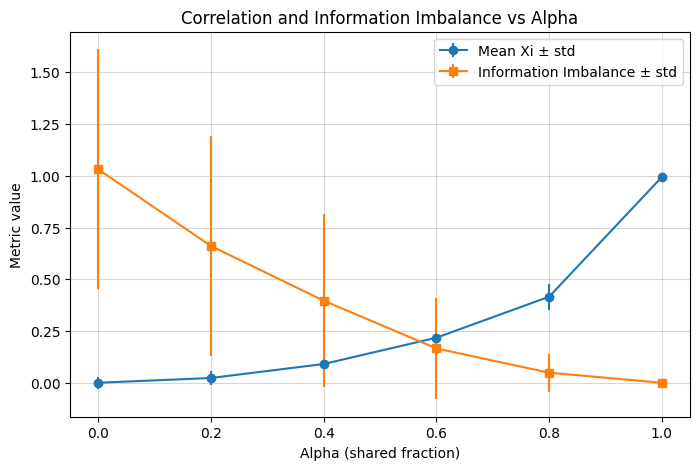

In [46]:
# -------------------------------------------------------------------------
# Loop over alphas (store means of each metric)
# -------------------------------------------------------------------------
alphas = np.linspace(0.0, 1.0, 6)
mean_xis, std_xis, inf_imbs, inf_imbs_std = [], [], [], []

for alpha in alphas:
    mean_xi, std_xi, inf_imb, inf_imb_std = compute_metrics_for_alpha(
        alpha,
        data_key,
        Ns,
        N,
        get_similarities,
        rankdata_2D_ties,
        my_xi_fn,
        II_fn,
        keyX,
        keyY,
    )
    # Take mean across the array returned by the metric functions
    mean_xis.append(np.mean(np.array(mean_xi)))
    std_xis.append(np.mean(np.array(std_xi)))
    inf_imbs.append(np.mean(np.array(inf_imb)))
    inf_imbs_std.append(np.mean(np.array(inf_imb_std)))

# -------------------------------------------------------------------------
# Plotting function
# -------------------------------------------------------------------------
import matplotlib.pyplot as plt

def plot_alpha_metrics(alphas, mean_xis, std_xis, inf_imbs, inf_imbs_std):
    plt.figure(figsize=(8,5))
    plt.errorbar(alphas, mean_xis, yerr=std_xis, marker='o', label='Mean Xi ± std')
    plt.errorbar(alphas, inf_imbs, yerr=inf_imbs_std, marker='s', label='Information Imbalance ± std')
    plt.xlabel("Alpha (shared fraction)")
    plt.ylabel("Metric value")
    plt.title("Correlation and Information Imbalance vs Alpha")
    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.show()

# -------------------------------------------------------------------------
# Call plotting function
# -------------------------------------------------------------------------
plot_alpha_metrics(alphas, mean_xis, std_xis, inf_imbs, inf_imbs_std)


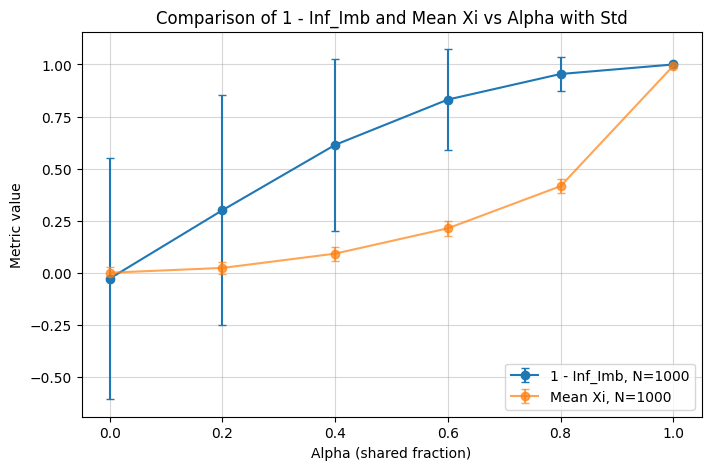

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# Settings
# -------------------------------------------------------------------------
Ns = 1000
alphas = np.linspace(0.0, 1.0, 6)
N_values = [1000]  # dynamically handle these

# Markers and line styles for plotting
markers = ['o', 's', '^', 'D', 'v']
lines = ['-', '--', '-.', ':']

# -------------------------------------------------------------------------
# Compute results with standard deviations
# -------------------------------------------------------------------------
results_inf = {}
results_inf_std = {}
results_xi = {}
results_xi_std = {}

for i, N in enumerate(N_values):
    inf_curve = []
    inf_curve_std = []
    xi_curve = []
    xi_curve_std = []
    for alpha in alphas:
        mean_xi, std_xi, inf_imb, inf_imb_std = compute_metrics_for_alpha(
            alpha,
            data_key,
            Ns,
            N,
            get_similarities,
            rankdata_2D_ties,
            my_xi_fn,
            II_fn,
            keyX,
            keyY,
        )
        # Take mean across the 2-element arrays
        inf_curve.append(1.0 - np.mean(np.array(inf_imb)))
        inf_curve_std.append(np.mean(np.array(inf_imb_std)))
        xi_curve.append(np.mean(np.array(mean_xi)))
        xi_curve_std.append(np.mean(np.array(std_xi)))
    
    results_inf[N] = inf_curve
    results_inf_std[N] = inf_curve_std
    results_xi[N] = xi_curve
    results_xi_std[N] = xi_curve_std

# -------------------------------------------------------------------------
# Elegant plotting
# -------------------------------------------------------------------------
plt.figure(figsize=(8,5))

for i, N in enumerate(N_values):
    marker = markers[i % len(markers)]
    line = lines[i % len(lines)]
    
    # 1 - Information Imbalance
    plt.errorbar(alphas, results_inf[N], yerr=results_inf_std[N], fmt=marker+line, capsize=3,
                 label=f'1 - Inf_Imb, N={N}')
    
    # Mean Xi
    plt.errorbar(alphas, results_xi[N], yerr=results_xi_std[N], fmt=marker+line, capsize=3,
                 label=f'Mean Xi, N={N}', alpha=0.7)

plt.xlabel("Alpha (shared fraction)")
plt.ylabel("Metric value")
plt.title("Comparison of 1 - Inf_Imb and Mean Xi vs Alpha with Std")
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()
